# YOLOv8 Traffic Sign Detection
This notebook prepares a YOLOv8 dataset (with pseudo bounding boxes) and trains a YOLOv8 model using the Ultralytics API.
Replace pseudo boxes with real annotations for proper detection performance.

In [22]:
!pip install --quiet ultralytics opencv-python tqdm

In [23]:
import os, shutil, random, yaml, glob, cv2, math
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import numpy as np
from ultralytics import YOLO  # currently loads latest (e.g., YOLOv8); treat as placeholder for YOLOv11

BASE_DIR = os.path.abspath('..')
RAW_TRAIN_DIR = os.path.join(BASE_DIR, 'archive', 'Train')  # class folders 0..42
OUTPUT_ROOT = os.path.join(os.getcwd(), 'data')  # YOLO dataset root inside YOLOv11 folder
IM_TRAIN = os.path.join(OUTPUT_ROOT, 'images', 'train')
IM_VAL = os.path.join(OUTPUT_ROOT, 'images', 'val')
LB_TRAIN = os.path.join(OUTPUT_ROOT, 'labels', 'train')
LB_VAL = os.path.join(OUTPUT_ROOT, 'labels', 'val')

for d in [IM_TRAIN, IM_VAL, LB_TRAIN, LB_VAL]:
    os.makedirs(d, exist_ok=True)

NUM_CLASSES = 43
IMG_SIZE = 64  # detection models can train bigger than 32
TEST_SIZE = 0.15
RANDOM_STATE = 42

In [24]:
import torch, os
# Prefer Apple Silicon MPS if available, else CUDA, else CPU
if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
# Optional: enable fallback for missing MPS kernels
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
print(f'Using device: {DEVICE}')

Using device: mps


In [25]:
%matplotlib inline
import matplotlib
from matplotlib import rcParams
rcParams['figure.dpi'] = 120
print('Inline matplotlib backend active (dpi=120).')

Inline matplotlib backend active (dpi=120).


## 1. Gather image paths and labels from classification folders

In [26]:
image_label_pairs = []
for cls in range(NUM_CLASSES):
    class_dir = os.path.join(RAW_TRAIN_DIR, str(cls))
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(('.png','.jpg','.jpeg')):
            image_label_pairs.append((os.path.join(class_dir, fname), cls))

print('Total images found:', len(image_label_pairs))

Total images found: 39209


## 2. Train/Val split

In [27]:
train_pairs, val_pairs = train_test_split(image_label_pairs, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=[lbl for _, lbl in image_label_pairs])
print(len(train_pairs), 'train,', len(val_pairs), 'val')

33327 train, 5882 val


## 3. Pseudo bounding box generator
We don't have real boxes; we approximate by placing a centered square box covering most of the image. Replace with real annotations when available.

In [28]:
def pseudo_box(w, h, scale=0.9):
    side = int(min(w, h) * scale)
    x1 = (w - side)//2
    y1 = (h - side)//2
    x2 = x1 + side
    y2 = y1 + side
    return x1, y1, x2, y2

## 4. Convert to YOLO format
YOLO label format per line: class cx cy w h (all normalized).

In [29]:
def convert_and_copy(pairs, im_dest, lb_dest):
    for path, cls in tqdm(pairs):
        img = cv2.imread(path)
        if img is None: continue
        h, w = img.shape[:2]
        # optional resize to IMG_SIZE square for consistency in pseudo boxes (model can resize itself)
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        out_img_name = os.path.splitext(os.path.basename(path))[0] + '.jpg'
        out_img_path = os.path.join(im_dest, out_img_name)
        cv2.imwrite(out_img_path, img_resized)
        # pseudo box on resized dims
        x1,y1,x2,y2 = pseudo_box(IMG_SIZE, IMG_SIZE)
        bw = x2 - x1
        bh = y2 - y1
        cx = x1 + bw/2
        cy = y1 + bh/2
        # normalize
        nx = cx / IMG_SIZE
        ny = cy / IMG_SIZE
        nw = bw / IMG_SIZE
        nh = bh / IMG_SIZE
        label_path = os.path.join(lb_dest, out_img_name.replace('.jpg', '.txt'))
        with open(label_path, 'w') as f:
            f.write(f'{cls} {nx:.6f} {ny:.6f} {nw:.6f} {nh:.6f}\n')

convert_and_copy(train_pairs, IM_TRAIN, LB_TRAIN)
convert_and_copy(val_pairs, IM_VAL, LB_VAL)
print('Conversion complete.')

100%|██████████| 5882/5882 [00:02<00:00, 2074.38it/s]

Conversion complete.


## 5. Create data.yaml dynamically (overriding static if desired)

In [30]:
yaml_dict = {
    'path': os.path.abspath('data'),
    'train': 'images/train',
    'val': 'images/val',
    'nc': NUM_CLASSES,
    'names': [str(i) for i in range(NUM_CLASSES)]  # use simple names or map later
}
with open('data_auto.yaml','w') as f: yaml.dump(yaml_dict, f)
print('data_auto.yaml written.')

data_auto.yaml written.


## 6. Train YOLOv8 model
Adjust epochs/imgsz/batch as needed.

In [31]:
model = YOLO('yolov8n.pt')  # using YOLOv8 nano variant
print(f'Training on device: {DEVICE}')
results = model.train(data='data_auto.yaml', epochs=25, imgsz=IMG_SIZE, batch=32, project='runs', name='yolov8_signs', device=DEVICE)


Training on device: mps


/Users/komalsaivulchi/Downloads/traffic-sign-detection-main/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


New https://pypi.org/project/ultralytics/8.3.226 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.204 🚀 Python-3.9.6 torch-2.8.0 MPS (Apple M2)
Ultralytics 8.3.204 🚀 Python-3.9.6 torch-2.8.0 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_auto.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_sign

## 6A. Training history: accuracy (mAP50) and loss curves (run after training)

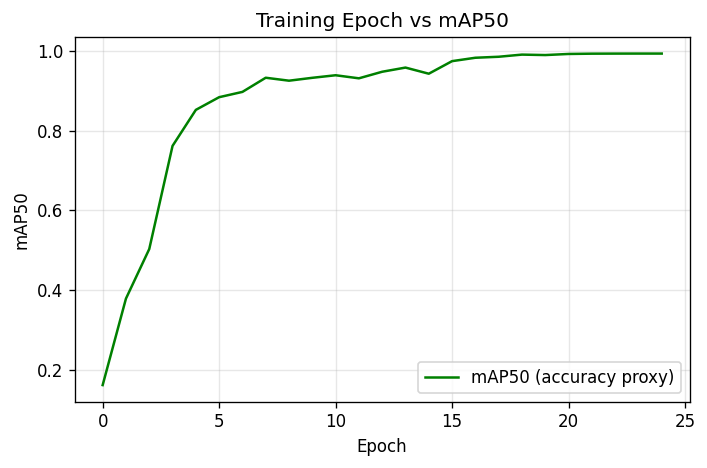

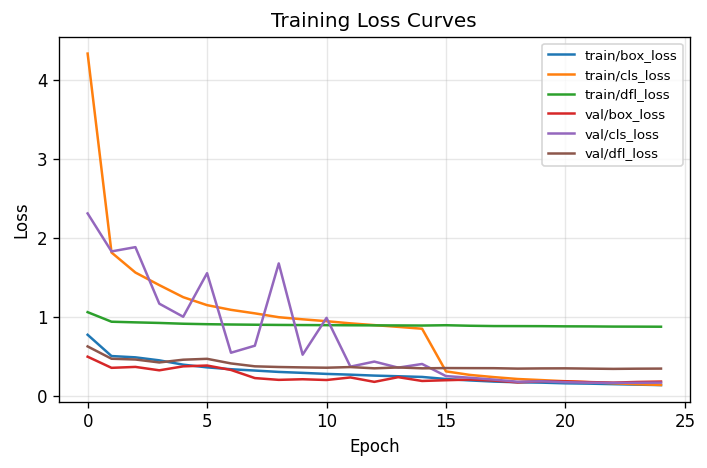

Best mAP50: 0.9945 at epoch 23


In [32]:
# COMPULSORY AFTER TRAINING (skips if no training history) - Plot mAP50 (accuracy proxy) and losses
import os, json, re, matplotlib.pyplot as plt
from pathlib import Path

run_dir = Path('runs')/RUN_NAME
metrics_file = None
# Ultralytics writes results.csv and results*.txt; parse CSV if present
for cand in ['results.csv','results.txt']:  # try csv first
    p = run_dir/cand
    if p.exists():
        metrics_file = p
        break

if metrics_file is None:
    # Fallback: search glob
    csvs = list(run_dir.glob('**/results.csv'))
    if csvs:
        metrics_file = csvs[0]

if metrics_file and metrics_file.name.endswith('.csv'):
    import pandas as pd
    df = pd.read_csv(metrics_file)
    # Expected columns include: epoch, train/val losses, metrics like metrics/mAP50, metrics/mAP50-95, etc.
    # Detect possible column names
    mAP_col = None
    for c in df.columns:
        if 'metrics/mAP50' in c or re.fullmatch(r'mAP50', c):
            mAP_col = c; break
    if mAP_col is None:
        # Try any column containing mAP50
        poss = [c for c in df.columns if 'mAP50' in c]
        mAP_col = poss[0] if poss else None

    loss_cols = [c for c in df.columns if 'loss' in c.lower()]
    if mAP_col:
        plt.figure(figsize=(6,4), dpi=120)
        plt.plot(df[mAP_col], label='mAP50 (accuracy proxy)', color='green')
        plt.xlabel('Epoch')
        plt.ylabel('mAP50')
        plt.title('Training Epoch vs mAP50')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print('mAP50 column not found in results file columns:', df.columns.tolist())

    if loss_cols:
        plt.figure(figsize=(6,4), dpi=120)
        for c in loss_cols:
            plt.plot(df[c], label=c)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss Curves')
        plt.grid(alpha=0.3)
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print('No loss columns detected in results file.')

    if mAP_col:
        best_epoch = int(df[mAP_col].idxmax())
        best_map = float(df[mAP_col].max())
        print(f'Best mAP50: {best_map:.4f} at epoch {best_epoch}')
else:
    print('Training metrics file not found. Run training first or ensure runs directory is intact.')

## 7. Validation metrics

In [33]:
metrics = model.val()
metrics

Ultralytics 8.3.204 🚀 Python-3.9.6 torch-2.8.0 MPS (Apple M2)
Model summary (fused): 72 layers, 3,014,033 parameters, 0 gradients, 8.1 GFLOPs
Model summary (fused): 72 layers, 3,014,033 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11.6±4.3 MB/s, size: 2.0 KB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11.6±4.3 MB/s, size: 2.0 KB)
val: Scanning /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/data/labels/val.cache... 5882 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5882/5882 13.0Mit/s 0.0ss
val: Scanning /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/data/labels/val.cache... 5882 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5882/5882 13.0Mit/s 0.0ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 184/184 2.7it/s 1:090.3sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x14b2dd0a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.03603

## 8. Inference on random validation images

In [34]:
sample_imgs = random.sample(glob.glob(os.path.join(IM_VAL,'*.jpg')), 5)
pred_dir = 'inference_samples'
os.makedirs(pred_dir, exist_ok=True)
for img_path in sample_imgs:
    res = model.predict(source=img_path, save=True, project=pred_dir, name='predictions', exist_ok=True)
sample_imgs


image 1/1 /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/data/images/val/00010_00024_00009.jpg: 64x64 1 10, 7.0ms
Speed: 6.5ms preprocess, 7.0ms inference, 231.2ms postprocess per image at shape (1, 3, 64, 64)
Results saved to /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/inference_samples/predictions

image 1/1 /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/data/images/val/00010_00024_00009.jpg: 64x64 1 10, 7.0ms
Speed: 6.5ms preprocess, 7.0ms inference, 231.2ms postprocess per image at shape (1, 3, 64, 64)
Results saved to /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/inference_samples/predictions

image 1/1 /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/data/images/val/00004_00001_00024.jpg: 64x64 1 4, 7.0ms
Speed: 0.5ms preprocess, 7.0ms inference, 7.8ms postprocess per image at shape (1, 3, 64, 64)
Results saved to /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/

['/Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/data/images/val/00010_00024_00009.jpg',
 '/Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/data/images/val/00004_00001_00024.jpg',
 '/Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/data/images/val/00008_00045_00002.jpg',
 '/Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/data/images/val/00012_00047_00020.jpg',
 '/Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/data/images/val/00034_00009_00013.jpg']

Prediction directory: /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/inference_samples/predictions
Predicted files sample: ['00002_00057_00004.jpg', '00004_00001_00024.jpg', '00006_00011_00000.jpg', '00008_00045_00002.jpg', '00010_00024_00009.jpg', '00010_00042_00023.jpg', '00012_00047_00020.jpg', '00025_00001_00015.jpg', '00026_00006_00025.jpg', '00034_00009_00013.jpg']


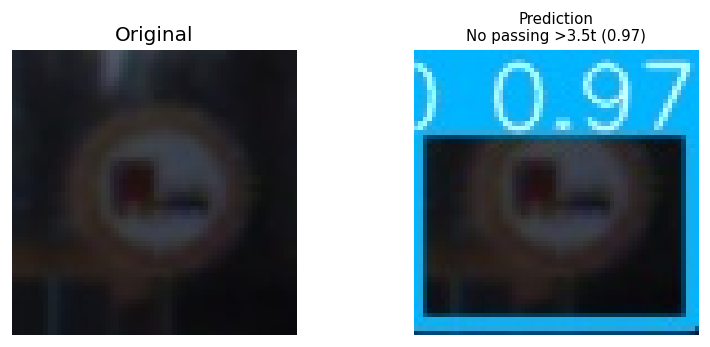

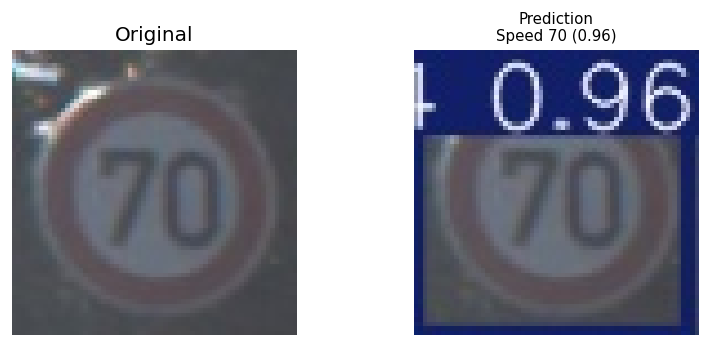

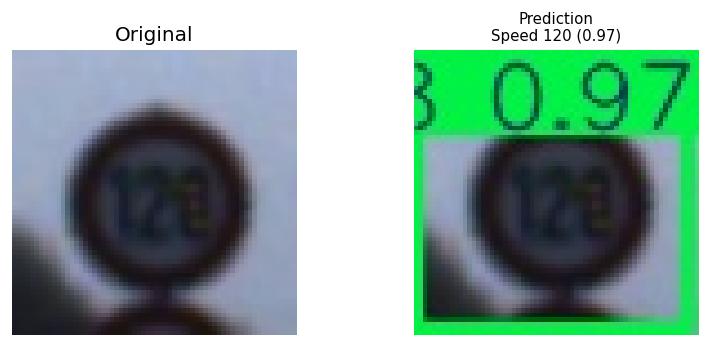

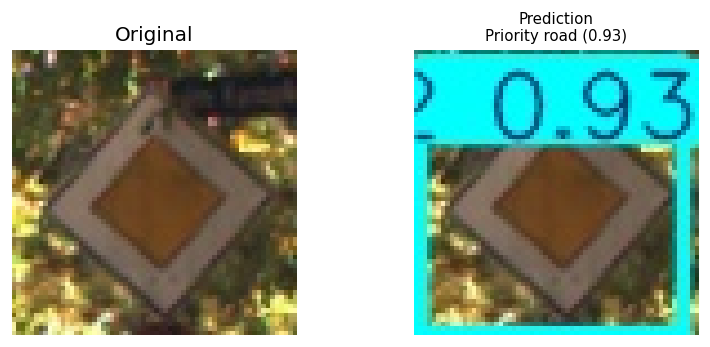

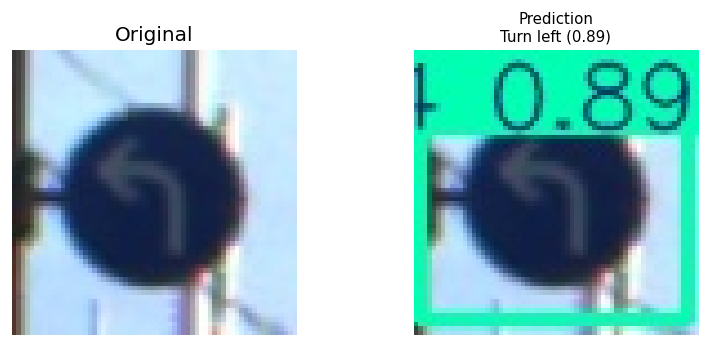

Display complete with class names & confidences. Saved comparison images to /Users/komalsaivulchi/Downloads/traffic-sign-detection-main/YOLOv11/inference_samples/comparisons


In [35]:
# Robust display of original vs predicted annotated images (inline) with class name & confidence
from IPython.display import display
import matplotlib.pyplot as plt
from PIL import Image as PILImage
import glob, os
import numpy as np

# Define human-readable label names (reuse if already defined elsewhere)
label_names = [
    'Speed 20','Speed 30','Speed 50','Speed 60','Speed 70','Speed 80','End 80','Speed 100','Speed 120',
    'No passing','No passing >3.5t','Right-of-way next','Priority road','Yield','Stop','No vehicles',
    '>3.5t prohibited','No entry','General caution','Left curve','Right curve','Double curve','Bumpy road',
    'Slippery','Road narrows right','Road work','Traffic signals','Pedestrians','Children','Bicycles','Ice/Snow',
    'Wild animals','End limits','Turn right','Turn left','Ahead only','Go straight or right','Go straight or left',
    'Keep right','Keep left','Roundabout','End no passing','End no passing >3.5t'
]

pred_out_dir = os.path.join('inference_samples','predictions')
print('Prediction directory:', os.path.abspath(pred_out_dir))
print('Predicted files sample:', sorted(os.listdir(pred_out_dir))[:10] if os.path.isdir(pred_out_dir) else 'Missing directory')

# Ensure sample_imgs exists (if notebook rerun partially, recreate a small sample)
if 'sample_imgs' not in globals() or len(sample_imgs) == 0:
    sample_imgs = sorted(glob.glob(os.path.join(IM_VAL,'*.jpg')))[:5]

save_comparison_dir = 'inference_samples/comparisons'
os.makedirs(save_comparison_dir, exist_ok=True)

for orig_path in sample_imgs:
    base = os.path.basename(orig_path)
    pred_path = os.path.join(pred_out_dir, base)
    if not os.path.exists(pred_path):
        stem = os.path.splitext(base)[0]
        cands = glob.glob(os.path.join(pred_out_dir, f"{stem}*"))
        if cands:
            pred_path = cands[0]

    # Run a quick prediction (without saving) to extract top class + confidence
    yolo_res = model.predict(source=orig_path, conf=0.05, imgsz=IMG_SIZE, save=False, verbose=False, device=DEVICE)
    top_label = 'No detection'
    if yolo_res and len(yolo_res[0].boxes) > 0:
        boxes = yolo_res[0].boxes
        confs = boxes.conf.cpu().numpy()
        idx = confs.argmax()
        cls_id = int(boxes[idx].cls.item())
        conf_val = float(boxes[idx].conf.item())
        top_label = f"{label_names[cls_id]} ({conf_val:.2f})"

    orig_img = PILImage.open(orig_path)
    pred_img = PILImage.open(pred_path) if os.path.exists(pred_path) else None

    fig, axs = plt.subplots(1,2, figsize=(7,3), dpi=120)
    axs[0].imshow(orig_img)
    axs[0].set_title('Original')
    axs[0].axis('off')
    if pred_img:
        axs[1].imshow(pred_img)
        axs[1].set_title(f'Prediction\n{top_label}', fontsize=9)
        axs[1].axis('off')
    else:
        axs[1].text(0.5,0.5,'Prediction not found', ha='center', va='center')
        axs[1].set_title(top_label, fontsize=9)
        axs[1].axis('off')

    fig.tight_layout()
    comp_path = os.path.join(save_comparison_dir, f'cmp_{base}')
    fig.savefig(comp_path, bbox_inches='tight')
    display(fig)
    plt.close(fig)

print('Display complete with class names & confidences. Saved comparison images to', os.path.abspath(save_comparison_dir))

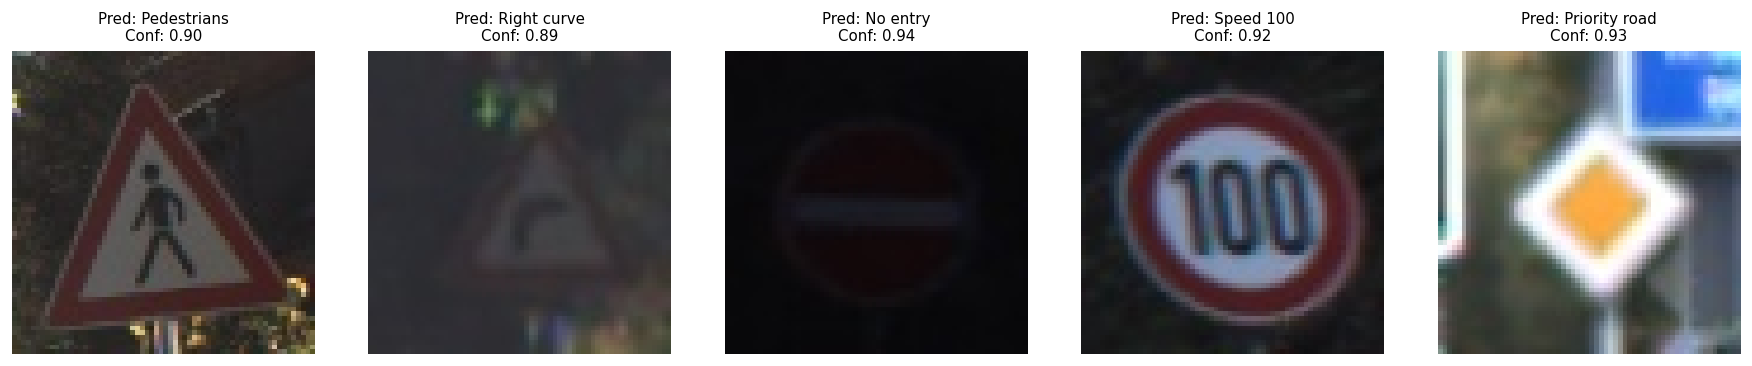

Displayed YOLOv8 predictions in grid.


In [36]:
# YOLOv8 CNN-style visualization: show images with predicted top class label only
import random, os, numpy as np, matplotlib.pyplot as plt
from PIL import Image as PILImage

# Traffic sign label names (replace with full descriptive names if desired)
label_names = [
    'Speed 20','Speed 30','Speed 50','Speed 60','Speed 70','Speed 80','End 80','Speed 100','Speed 120',
    'No passing','No passing >3.5t','Right-of-way next','Priority road','Yield','Stop','No vehicles',
    '>3.5t prohibited','No entry','General caution','Left curve','Right curve','Double curve','Bumpy road',
    'Slippery','Road narrows right','Road work','Traffic signals','Pedestrians','Children','Bicycles','Ice/Snow',
    'Wild animals','End limits','Turn right','Turn left','Ahead only','Go straight or right','Go straight or left',
    'Keep right','Keep left','Roundabout','End no passing','End no passing >3.5t'
]

num_images = 5
# Use validation images prepared earlier
all_val_imgs = sorted(glob.glob(os.path.join(IM_VAL, '*.jpg')))
subset = random.sample(all_val_imgs, min(num_images, len(all_val_imgs)))

plt.figure(figsize=(3*num_images, 3))
for i, img_path in enumerate(subset):
    # Run detection
    results = model.predict(source=img_path, conf=0.05, imgsz=IMG_SIZE, save=False, verbose=False, device=DEVICE)
    img = PILImage.open(img_path).convert('RGB')

    title = 'No detection'
    if results and len(results[0].boxes) > 0:
        boxes = results[0].boxes
        confs = boxes.conf.cpu().numpy()
        idx = confs.argmax()
        cls_id = int(boxes[idx].cls.item())
        conf_val = float(boxes[idx].conf.item())
        title = f"Pred: {label_names[cls_id]}\nConf: {conf_val:.2f}"
    
    ax = plt.subplot(1, num_images, i+1)
    ax.imshow(img)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()
print('Displayed YOLOv8 predictions in grid.')

## 9. Notes
- Replace pseudo boxes with real annotations for meaningful detection performance.
- Increase image size (e.g., 128, 256) for better accuracy.
- Choose a larger model variant for higher accuracy (yolov8m, yolov8l, etc.).
- When YOLOv11 releases, adjust import and checkpoint names.